#### Video Game Sales Strategy Analysis
##### Cliente: ICE, tienda online de videojuegos
##### Objetivo: identificar patrones comerciales relevantes para apoyar la planificación publicitaria de 2017.

### Limpieza y preparación de datos
Las columnas se normalizan a minúsculas, se eliminan espacios innecesarios y se ajustan los valores a formatos numéricos. Los registros marcados como `tbd` se tratan como valores ausentes para evitar distorsiones en los cálculos.

`user_score` se convierte a formato numérico y `critic_score` se homologa a la escala de User Score. Los valores ausentes en User Score, Critic Score y ESRB Rating se consideran caveats de calidad de datos y se interpretan con cautela en el análisis posterior.

In [118]:
import pandas as pd
import numpy as np
import re
from scipy import stats
import seaborn as sns
from matplotlib import pyplot as plt


In [119]:
from pathlib import Path

DATA_PATH = Path("../data/games.csv")
games = pd.read_csv(DATA_PATH)
games = games

games.columns = (games.columns.str.lower().str.strip().str.replace(' ', '_'))

REPLACEMENTS = {
    "tbd": pd.NA,
    "n/a": pd.NA,
    "na": pd.NA,
    "none": pd.NA,
    "null": pd.NA,
    "": pd.NA,          # vacíos a NA
}

def convertir(x):
    if isinstance(x, str):
        x = x.strip().lower()
        x = re.sub(r"\s+", " ", x)         # cualquier whitespace repetido -> 1 espacio
        return REPLACEMENTS.get(x, x)      # si x está en el diccionario, reemplaza
    return x

games = games.map(convertir)

col = "user_score"

games[col] = pd.to_numeric(games[col], errors="coerce")

games['critic_score']=(games['critic_score']/10)

games.info()

print()

games.sample(5)

<class 'pandas.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  str    
 1   platform         16715 non-null  str    
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  str    
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   str    
dtypes: float64(7), str(4)
memory usage: 2.0 MB



,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
16215,hitotsu tobashi renai v,psv,2015.0,adventure,0.00,0.00,0.01,0.00,NaN,NaN,NaN
649,pro evolution soccer 2011,ps3,2010.0,sports,0.29,1.17,0.54,0.41,7.7,6.8,e
7562,x2: wolverine's revenge,gba,2003.0,platform,0.14,0.05,0.00,0.00,7.2,7.2,e
3121,super robot taisen impact,ps2,2002.0,strategy,0.00,0.00,0.65,0.00,NaN,NaN,NaN
1192,donkey kong classics,nes,1988.0,platform,0.59,0.14,0.81,0.02,NaN,NaN,NaN


Control de calidad de valores ausentes y revisión de su peso relativo dentro del dataset.

In [120]:
print(games['critic_score'].isnull().sum())
print(games['user_score'].isnull().sum())
print(games['critic_score'].isnull().mean())
print(games['user_score'].isnull().mean())

print(games['critic_score'].sample(10))
print(games['user_score'].sample(10))


8578
9125
0.5131917439425665
0.5459168411606342
4543     4.6
12406    7.2
5816     NaN
13524    NaN
5893     NaN
7288     5.1
8134     NaN
13117    2.6
4963     8.2
8550     4.7
Name: critic_score, dtype: float64
15138    NaN
9794     7.6
14961    NaN
4870     NaN
1651     8.4
648      8.2
9335     4.0
15073    6.9
14318    NaN
5492     NaN
Name: user_score, dtype: float64


Exploración inicial de ventas regionales.

In [121]:
games.agg(
    {'na_sales': ['sum', 'min', 'max'],
    'eu_sales': ['sum', 'min', 'max'],
     'jp_sales':['sum', 'min', 'max'],
}
)


,na_sales,eu_sales,jp_sales
sum,4402.35,2424.67,1297.37
min,0.00,0.00,0.00
max,41.36,28.96,10.22


### Preparación temporal y ventas totales
El dataset se organiza por `year_of_release` para analizar la evolución temporal de lanzamientos, plataformas y ventas acumuladas. También se calcula `total_sales` como suma de las ventas regionales, manteniendo una métrica consistente para las comparaciones posteriores.

In [122]:
sales_cols = ["na_sales", "eu_sales", "jp_sales", "other_sales"]

games["total_sales"] = games[sales_cols].sum(axis=1)

games_by_year = games[

    ['platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']

].copy()



games_by_year = games_by_year.set_index('year_of_release').sort_index()



games_by_year.info()

games_by_year

<class 'pandas.DataFrame'>
Index: 16715 entries, 1980.0 to nan
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   platform     16715 non-null  str    
 1   genre        16713 non-null  str    
 2   na_sales     16715 non-null  float64
 3   eu_sales     16715 non-null  float64
 4   jp_sales     16715 non-null  float64
 5   other_sales  16715 non-null  float64
 6   total_sales  16715 non-null  float64
dtypes: float64(5), str(2)
memory usage: 1.2 MB


,platform,genre,na_sales,eu_sales,jp_sales,other_sales,total_sales
year_of_release,,,,,,,
1980.0,2600,sports,0.46,0.03,0.0,0.01,0.50
1980.0,2600,shooter,2.56,0.17,0.0,0.03,2.76
1980.0,2600,fighting,0.72,0.04,0.0,0.01,0.77
1980.0,2600,misc,0.22,0.01,0.0,0.00,0.23
1980.0,2600,misc,0.99,0.05,0.0,0.01,1.05
...,...,...,...,...,...,...,...
NaN,psp,sports,0.01,0.00,0.0,0.00,0.01
NaN,gc,racing,0.01,0.00,0.0,0.00,0.01
NaN,pc,shooter,0.01,0.00,0.0,0.00,0.01


Análisis por plataforma, ventas acumuladas y volumen de lanzamientos por periodo. Las figuras históricas previas a 2010 se omiten como visualizaciones principales para mantener el foco en la planificación publicitaria de 2017.

In [123]:
# Convierto el índice a numérico para asegurar su manipulación.

years = pd.to_numeric(games_by_year.index, errors="coerce") 

# Creo un diccionario con los rangos de decadas

decade_ranges = {
    'ochentas' : (1980, 1990),
    'noventas' : (1990, 2000),
    'dosmil' : (2000, 2010),
    'dosmildiez' : (2010, 2020)
}

# Creo un diccionario que contendra los DataFrames por decada

df_decadas = {}

# Creo un bucle for con el cual examino cada item de decade_ranges para asignar mi nuevo DataFrame por decadas. Uso una mascara booleana para ello. 

for nombre, (inicio, fin) in decade_ranges.items():
    mascara = (years >= inicio) & (years < fin)
    df_decadas[nombre] = games_by_year[mascara]

print(df_decadas.keys())


dict_keys(['ochentas', 'noventas', 'dosmil', 'dosmildiez'])


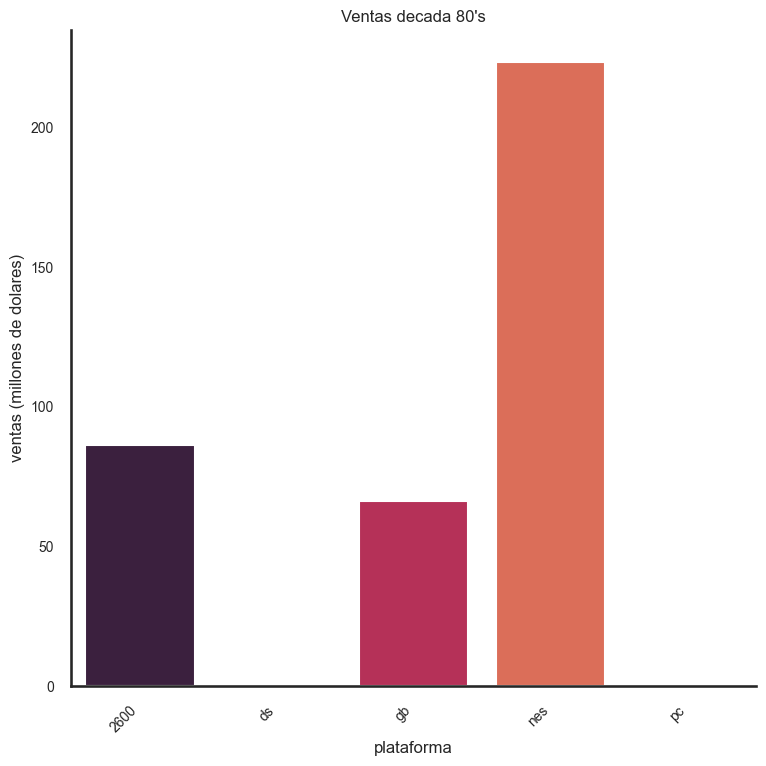

In [124]:
# Asigno a una variable cada DataFrame por decada para manipular facilmente. 

df_ochentas = df_decadas['ochentas']
df_noventas = df_decadas['noventas']
df_dosmil = df_decadas['dosmil']
df_dosmildiez = df_decadas['dosmildiez']

# Agrupo por plataforma y calculo ventas totales como primer análisis.

platform_sales_ochentas = (
    df_ochentas
      .groupby('platform', as_index=False)['total_sales']
      .sum()
)


sns.set_theme(style="white", context="talk")

plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=platform_sales_ochentas,
    x="platform",
    y="total_sales",     
    hue="platform",      
    palette="rocket",
    dodge=False
)

# Quitar leyenda de forma segura
leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.xlabel("plataforma", fontsize=12)
plt.ylabel("ventas (millones de dolares)", fontsize=12)
plt.title("Ventas decada 80's", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


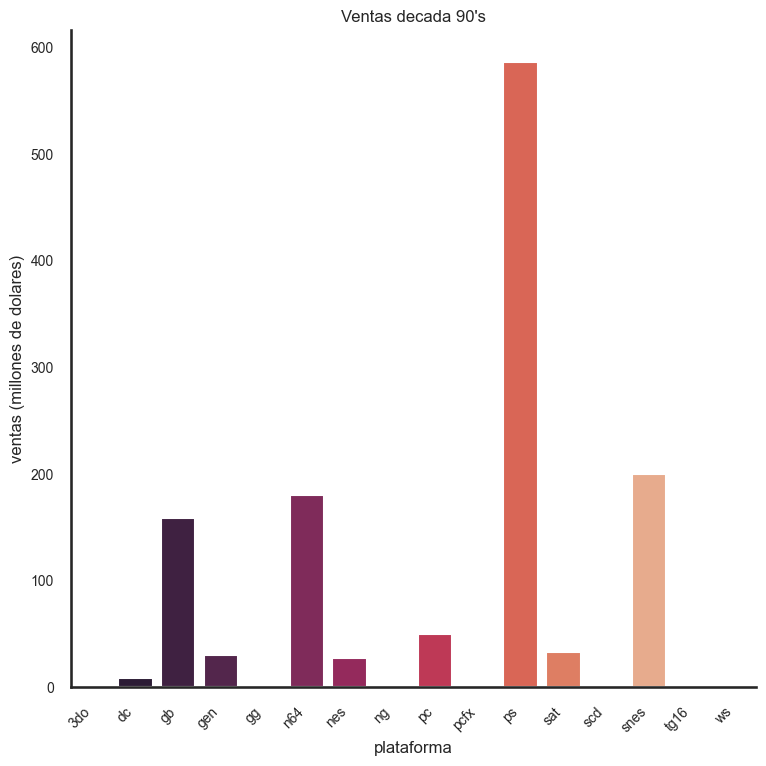

In [125]:
platform_sales_noventas = ( df_noventas.groupby('platform', as_index=False)[['total_sales']].sum())

plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=platform_sales_noventas,
    x="platform",
    y="total_sales",
    hue="platform",      # Evita advertencias de seaborn al definir hue sin separación de barras
    palette="rocket",
    dodge=False          # <- evita barras “duplicadas”/separadas
)

# Quitar leyenda de forma segura (sin usar legend=False)
leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.xlabel("plataforma", fontsize=12)
plt.ylabel("ventas (millones de dolares)", fontsize=12)
plt.title("Ventas decada 90's", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()



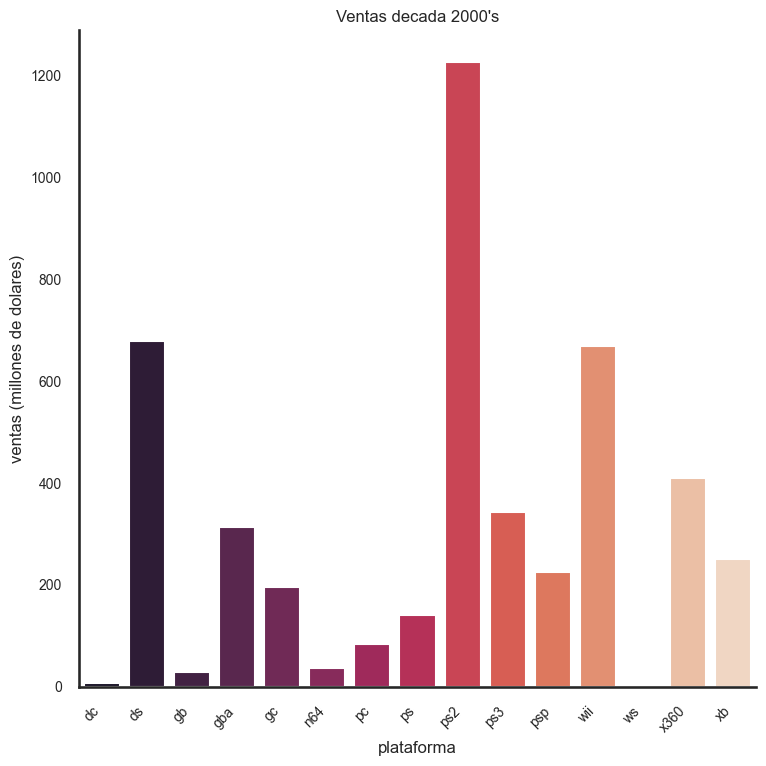

In [126]:
platform_sales_dosmil = (df_dosmil.groupby('platform', as_index=False)[['total_sales']].sum())

sns.set_theme(style="white", context="talk")

plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=platform_sales_dosmil,
    x="platform",
    y="total_sales",      # si renombraste, cambia a "total_sales_2000"
    hue="platform",       # Evita advertencias de seaborn al usar hue con barras no separadas
    palette="rocket",
    dodge=False
)

# Quitar leyenda (sin legend=False)
leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.xlabel("plataforma", fontsize=12)
plt.ylabel("ventas (millones de dolares)", fontsize=12)
plt.title("Ventas decada 2000's", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

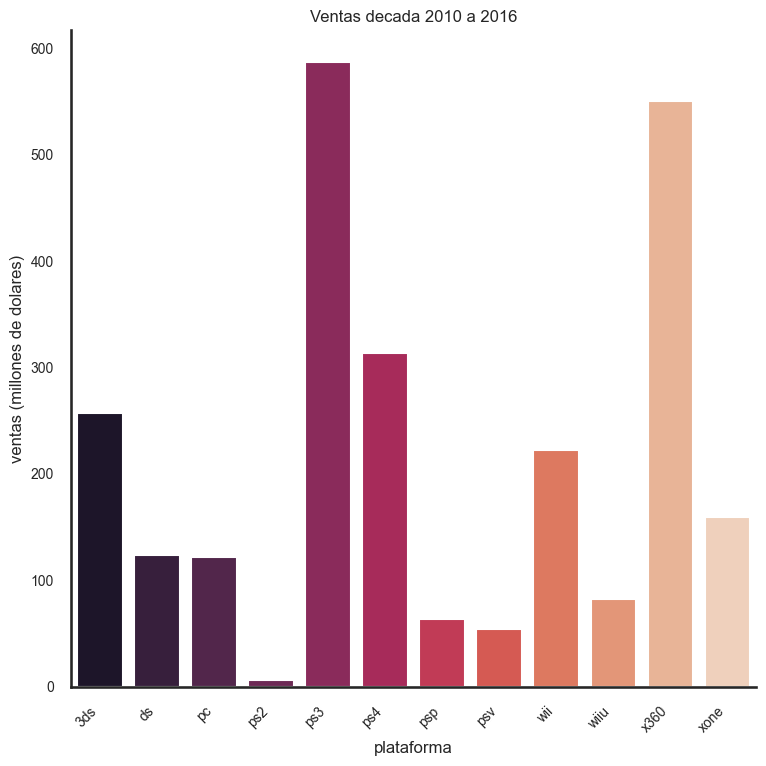

In [127]:
platform_sales_dosmildiez = (df_dosmildiez.groupby('platform', as_index=False)[['total_sales']].sum())

sns.set_theme(style="white", context="talk")

plt.figure(figsize=(8, 8))
ax = sns.barplot(
    data=platform_sales_dosmildiez,
    x="platform",
    y="total_sales",          # si renombraste, cambia a "total_sales_2010_2016"
    hue="platform",           # Evita advertencias de seaborn al usar hue con barras no separadas
    palette="rocket",
    dodge=False
)

# Quitar leyenda de forma segura
leg = ax.get_legend()
if leg is not None:
    leg.remove()

plt.xlabel("plataforma", fontsize=12)
plt.ylabel("ventas (millones de dolares)", fontsize=12)
plt.title("Ventas decada 2010 a 2016", fontsize=12)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


Evolución anual de lanzamientos entre 1980 y 2016.

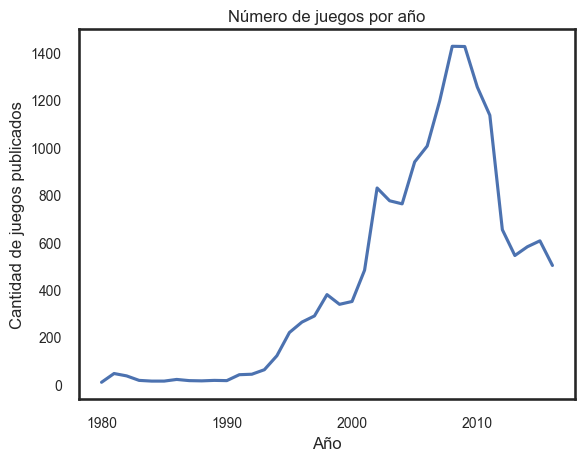

In [128]:

df_years = games[['year_of_release']].copy()
df_years = df_years.dropna(subset=['year_of_release'])
df_years['year_of_release'] = pd.to_numeric(df_years['year_of_release'], errors='coerce')
df_years = df_years.dropna(subset=['year_of_release'])
df_years['year_of_release'] = df_years['year_of_release'].astype(int)

juegos_por_anio = df_years.groupby('year_of_release').size().sort_index()

sns.lineplot(x=juegos_por_anio.index, y=juegos_por_anio.values)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad de juegos publicados", fontsize=12)
plt.title("Número de juegos por año", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

### Ventas por juego y región

Ventas acumuladas por plataforma y región.

In [129]:
df_regions= games[['platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales' ]]

regions = {
    'na_sales': 'total_na',
    'eu_sales': 'total_eu',
    'jp_sales': 'total_jp',
    'other_sales': 'total_other'
}

tabla_regiones = df[['platform']].drop_duplicates().sort_values('platform')

for sales_col, total_sales in regions.items():
    tabla = (
        df.groupby('platform', as_index=False)[sales_col]
        .sum()
        .rename(columns={sales_col: total_sales})
    )
    tabla_regiones = tabla_regiones.merge(tabla, on='platform', how='left')

tabla_regiones



,platform,total_na,total_eu,total_jp,total_other
0,2600,90.60,5.47,0.00,0.91
1,3do,0.00,0.00,0.10,0.00
2,3ds,83.49,61.48,100.67,13.36
3,dc,5.43,1.69,8.56,0.27
4,ds,382.40,188.89,175.57,59.26
5,gb,114.32,47.82,85.12,8.20
6,gba,187.54,75.25,47.33,7.73
7,gc,133.46,38.71,21.58,5.18
8,gen,21.05,6.05,2.70,0.97
9,gg,0.00,0.00,0.04,0.00


Plataformas líderes por ventas en cada región.

In [130]:
top_5_por_region = {}

for sales_col, total_sales in regions.items():
    top_5 = (
        df.groupby('platform', as_index=False)[sales_col]
        .sum()
        .rename(columns={sales_col: total_sales})
        .sort_values(by=total_sales, ascending=False)
        .head(5)
    )
    
    top_5_por_region[total_sales] = top_5

top_na = top_5_por_region['total_na']
top_eu = top_5_por_region['total_eu']
top_jp = top_5_por_region['total_jp']
top_other = top_5_por_region['total_other']

# Restablezco el índice para concatenar las tablas sin introducir valores NaN adicionales.

top_na = (
    df.groupby('platform', as_index=False)['na_sales']
    .sum()
    .rename(columns={'platform': 'platform_na', 'na_sales': 'total_na'})
    .sort_values(by='total_na', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_eu = (
    df.groupby('platform', as_index=False)['eu_sales']
    .sum()
    .rename(columns={'platform': 'platform_eu', 'eu_sales': 'total_eu'})
    .sort_values(by='total_eu', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_jp = (
    df.groupby('platform', as_index=False)['jp_sales']
    .sum()
    .rename(columns={'platform': 'platform_jp', 'jp_sales': 'total_jp'})
    .sort_values(by='total_jp', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

top_other = (
    df.groupby('platform', as_index=False)['other_sales']
    .sum()
    .rename(columns={'platform': 'platform_other', 'other_sales': 'total_other'})
    .sort_values(by='total_other', ascending=False)
    .head(5)
    .reset_index(drop=True)
)

tabla_final = pd.concat([top_na, top_eu, top_jp, top_other], axis=1)
tabla_final



,platform_na,total_na,platform_eu,total_eu,platform_jp,total_jp,platform_other,total_other
0,x360,602.47,ps2,339.29,ds,175.57,ps2,193.44
1,ps2,583.84,ps3,330.29,ps,139.82,ps3,135.68
2,wii,496.90,x360,270.76,ps2,139.20,x360,85.76
3,ps3,393.49,wii,262.21,snes,116.55,wii,79.07
4,ds,382.40,ps,213.61,3ds,100.67,ds,59.26


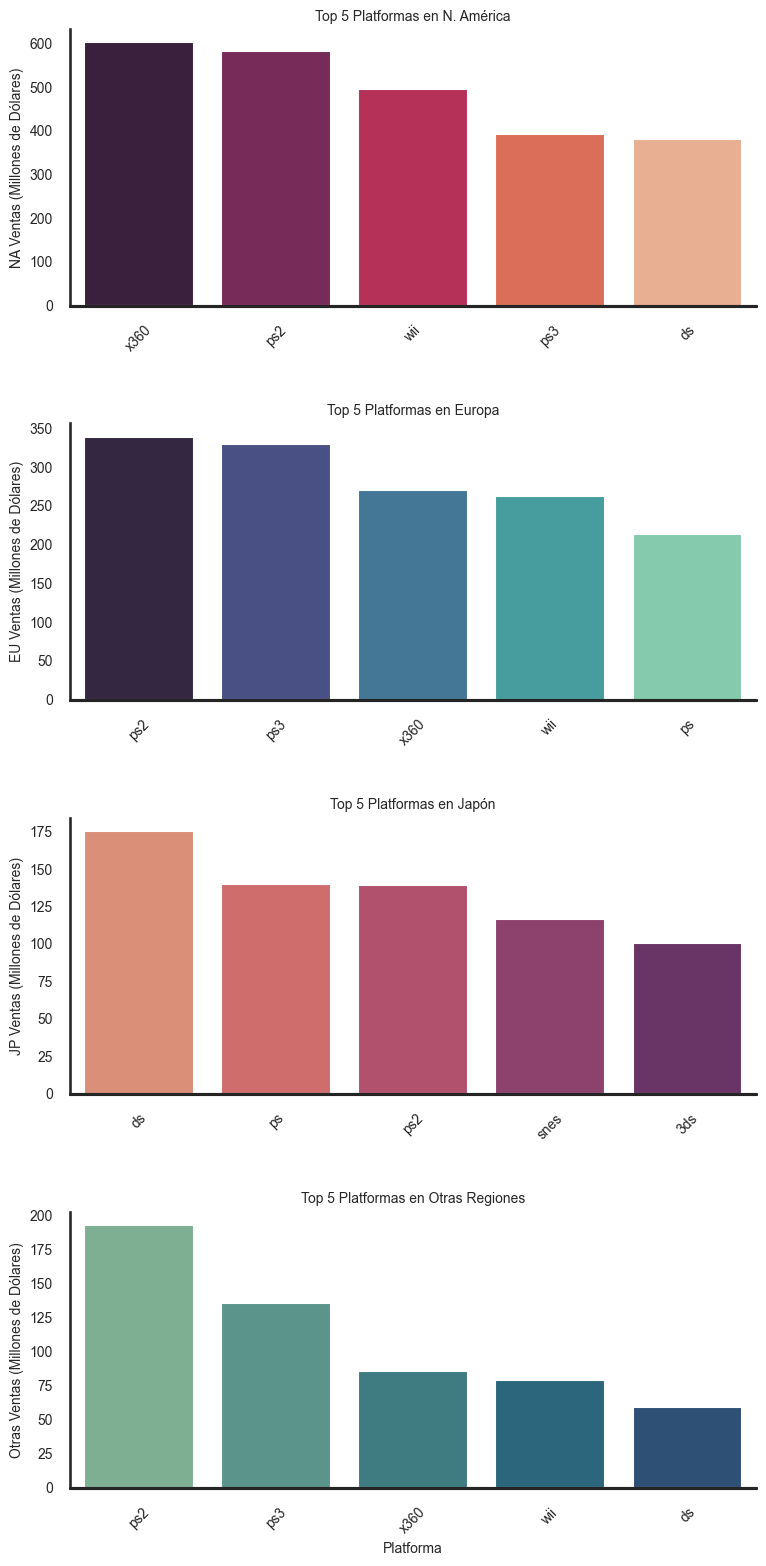

In [131]:
sns.set_theme(style="white", context="talk")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(8, 16))

# North America
sns.barplot(
    data=top_na,
    x='platform_na',
    y='total_na',
    hue='platform_na',
    palette='rocket',
    ax=ax1,
    legend=False
)
ax1.axhline(0, color='k', clip_on=False)
ax1.set_ylabel("NA Ventas (Millones de Dólares)", fontsize=10, rotation=90)
ax1.set_xlabel("", fontsize=10)
ax1.set_title("Top 5 Platformas en N. América", fontsize=10)

# Europe
sns.barplot(
    data=top_eu,
    x='platform_eu',
    y='total_eu',
    hue='platform_eu',
    palette='mako',
    ax=ax2,
    legend=False
)
ax2.axhline(0, color='k', clip_on=False)
ax2.set_ylabel("EU Ventas (Millones de Dólares)", fontsize=10, rotation=90)
ax2.set_xlabel("", fontsize=10)
ax2.set_title("Top 5 Platformas en Europa", fontsize=10)

# Japan
sns.barplot(
    data=top_jp,
    x='platform_jp',
    y='total_jp',
    hue='platform_jp',
    palette='flare',
    ax=ax3,
    legend=False
)
ax3.axhline(0, color='k', clip_on=False)
ax3.set_ylabel("JP Ventas (Millones de Dólares)", fontsize=10, rotation=90)
ax3.set_xlabel("", fontsize=10)
ax3.set_title("Top 5 Platformas en Japón", fontsize=10)

# Other regions
sns.barplot(
    data=top_other,
    x='platform_other',
    y='total_other',
    hue='platform_other',
    palette='crest',
    ax=ax4,
    legend=False
)
ax4.axhline(0, color='k', clip_on=False)
ax4.set_ylabel("Otras Ventas (Millones de Dólares)", fontsize=10, rotation=90)
ax4.set_xlabel("Platforma", fontsize=10)
ax4.set_title("Top 5 Platformas en Otras Regiones", fontsize=10)

# Apply fontsize=10 to tick labels too
for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.tick_params(axis='y', labelsize=10)

sns.despine()
plt.tight_layout(h_pad=2)
plt.show()

Plataformas con mayor volumen de ventas acumuladas en el periodo analizado.

In [132]:
platform_sales = (
    df.assign(total_sales=df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1))
      .groupby('platform', as_index=False)['total_sales']
      .sum()
      .sort_values(by='total_sales', ascending=False)
)

platform_sales.head(5)



,platform,total_sales
16,ps2,1255.77
28,x360,971.42
17,ps3,939.65
25,wii,907.51
4,ds,806.12


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_5712\1103531188.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


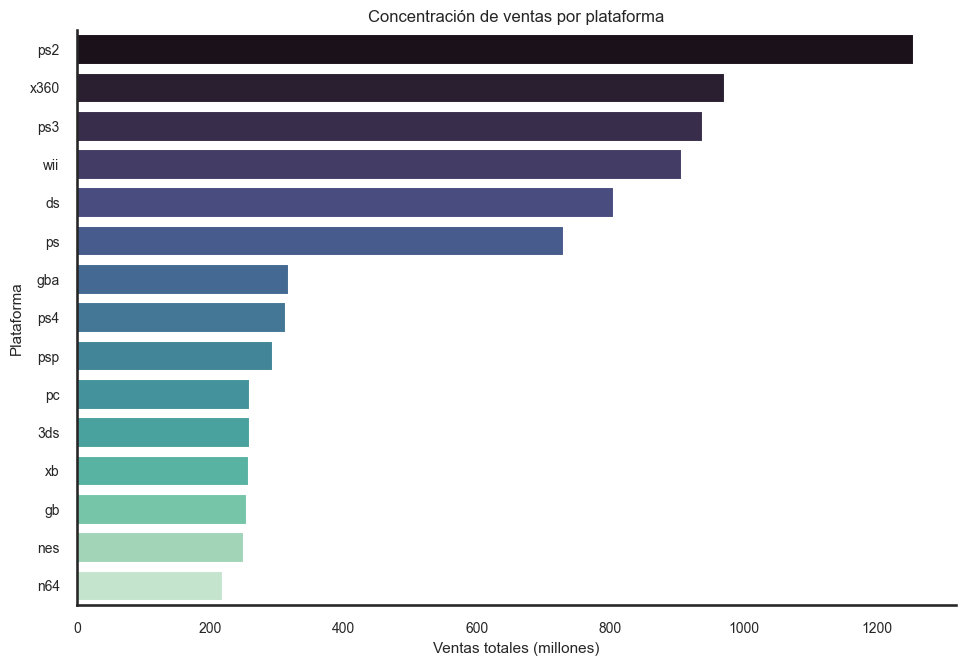

In [133]:
top_platforms = (
    platform_sales
    .sort_values("total_sales", ascending=False)
    .head(15)
)

sns.set_theme(style="white", context="talk")

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_platforms,
    x="total_sales",
    y="platform",
    palette="mako"
)

plt.xlabel("Ventas totales (millones)", fontsize=11)
plt.ylabel("Plataforma", fontsize=11)
plt.title("Concentración de ventas por plataforma", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()


### Vida útil de las plataformas

In [134]:
platform_life = (
    games.groupby('platform')['year_of_release']
    .agg(['min', 'max'])
    .reset_index()
    .rename(columns={
        'min': 'first_year',
        'max': 'last_year'
    })
)


platform_life['lifespan'] = platform_life['last_year'] - platform_life['first_year'] + 1
platform_life = platform_life.sort_values(by='lifespan', ascending=False)
print(platform_life.head(10))
print()

average_lifespan = platform_life['lifespan'].mean()
print("Rango de vida de las plataformas:", average_lifespan)

median_lifespan = platform_life['lifespan'].median()
print("Mediana del rango de vida de las plataformas:", median_lifespan)

max_platform = platform_life.loc[platform_life['lifespan'].idxmax()]
print("Máximo rango de vida de las plataformas:")
print(max_platform)

min_platform = platform_life.loc[platform_life['lifespan'].idxmin()]
print("Mínimo rango de vida de las plataformas:")
print(min_platform)

   platform  first_year  last_year  lifespan
13       pc      1985.0     2016.0      32.0
4        ds      1985.0     2013.0      29.0
5        gb      1988.0     2001.0      14.0
11      nes      1983.0     1994.0      12.0
28     x360      2005.0     2016.0      12.0
19      psp      2004.0     2015.0      12.0
16      ps2      2000.0     2011.0      12.0
17      ps3      2006.0     2016.0      11.0
3        dc      1998.0     2008.0      11.0
25      wii      2006.0     2016.0      11.0

Rango de vida de las plataformas: 8.612903225806452
Mediana del rango de vida de las plataformas: 7.0
Máximo rango de vida de las plataformas:
platform          pc
first_year    1985.0
last_year     2016.0
lifespan        32.0
Name: 13, dtype: object
Mínimo rango de vida de las plataformas:
platform          gg
first_year    1992.0
last_year     1992.0
lifespan         1.0
Name: 9, dtype: object


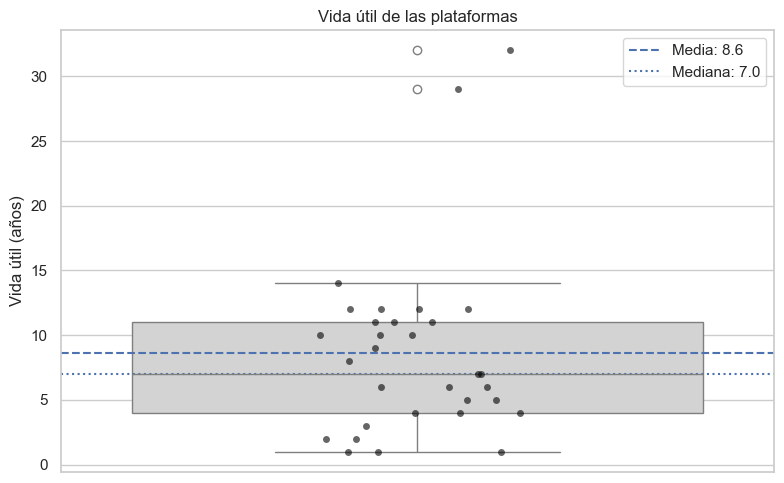

In [135]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 5))

sns.boxplot(
    y=platform_life["lifespan"],
    color="lightgray"
)

sns.stripplot(
    y=platform_life["lifespan"],
    color="black",
    alpha=0.6,
    jitter=0.15
)

mean_life = platform_life["lifespan"].mean()
median_life = platform_life["lifespan"].median()

plt.axhline(
    mean_life,
    linestyle="--",
    linewidth=1.5,
    label=f"Media: {mean_life:.1f}"
)

plt.axhline(
    median_life,
    linestyle=":",
    linewidth=1.5,
    label=f"Mediana: {median_life:.1f}"
)

plt.title("Vida útil de las plataformas")
plt.ylabel("Vida útil (años)")
plt.legend()

plt.tight_layout()
plt.show()


In [136]:
platform_life.describe()

,first_year,last_year,lifespan
count,31.000000,31.000000,31.000000
mean,1997.645161,2005.258065,8.612903
std,9.094131,9.273503,6.998464
min,1980.000000,1989.000000,1.000000
25%,1992.500000,1996.000000,4.000000
50%,1996.000000,2007.000000,7.000000
75%,2004.500000,2016.000000,11.000000
max,2013.000000,2016.000000,32.000000


Análisis de User Score y Critic Score por plataforma y género.

In [137]:
df_critic = games[['name', 'platform', 'genre', 'critic_score']]
df_critic = df_critic.sort_values(by='critic_score', ascending=False).reset_index(drop=True)

df_critic.head(10)

,name,platform,genre,critic_score
0,grand theft auto iv,ps3,action,9.8
1,soulcalibur,dc,fighting,9.8
2,tony hawk's pro skater 2,ps,sports,9.8
3,grand theft auto iv,x360,action,9.8
4,grand theft auto v,xone,action,9.7
5,nfl 2k1,dc,sports,9.7
6,grand theft auto v,ps4,action,9.7
7,tony hawk's pro skater 3,ps2,sports,9.7
8,grand theft auto iii,ps2,action,9.7
9,super mario galaxy 2,wii,platform,9.7


In [138]:
df_user = games[['name', 'platform', 'genre', 'user_score']]
df_user = df_user.sort_values(by='user_score', ascending = False).reset_index(drop=True)

df_user.head(10)

,name,platform,genre,user_score
0,breath of fire iii,psp,role-playing,9.7
1,boktai: the sun is in your hand,gba,role-playing,9.6
2,harvest moon: friends of mineral town,gba,simulation,9.6
3,cory in the house,ds,action,9.5
4,super puzzle fighter ii,gba,puzzle,9.5
5,karnaaj rally,gba,racing,9.5
6,golden sun: the lost age,gba,role-playing,9.5
7,wade hixton's counter punch,gba,sports,9.5
8,mlb slugfest loaded,ps2,sports,9.5
9,resident evil 4,gc,action,9.4


In [139]:
score_comparison = pd.concat([df_user,df_critic], axis=1)
score_comparison.head(10)

,name,platform,genre,user_score,name,platform,genre,critic_score
0,breath of fire iii,psp,role-playing,9.7,grand theft auto iv,ps3,action,9.8
1,boktai: the sun is in your hand,gba,role-playing,9.6,soulcalibur,dc,fighting,9.8
2,harvest moon: friends of mineral town,gba,simulation,9.6,tony hawk's pro skater 2,ps,sports,9.8
3,cory in the house,ds,action,9.5,grand theft auto iv,x360,action,9.8
4,super puzzle fighter ii,gba,puzzle,9.5,grand theft auto v,xone,action,9.7
5,karnaaj rally,gba,racing,9.5,nfl 2k1,dc,sports,9.7
6,golden sun: the lost age,gba,role-playing,9.5,grand theft auto v,ps4,action,9.7
7,wade hixton's counter punch,gba,sports,9.5,tony hawk's pro skater 3,ps2,sports,9.7
8,mlb slugfest loaded,ps2,sports,9.5,grand theft auto iii,ps2,action,9.7
9,resident evil 4,gc,action,9.4,super mario galaxy 2,wii,platform,9.7


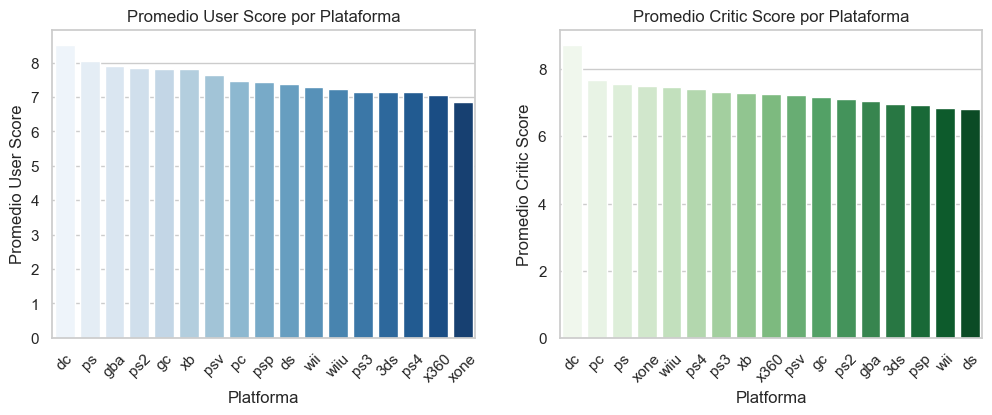

<Figure size 640x480 with 0 Axes>

In [140]:
range_score = {
    'user_score' : (5,10),
    'critic_score': (5,10)

}

df_score_filt = {}

for col, (low, high) in range_score.items():
    mask = (
        (games[col] >= low) &
        (games[col] <= high)
    )
    df_score_filt[col] = games.loc[mask, ['platform', 'genre', col]]

avg_user = (
    df_score_filt['user_score']
    .groupby('platform')['user_score']
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

avg_critic = (
    df_score_filt['critic_score']
    .groupby('platform')['critic_score']
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico user_score
sns.barplot(
    data=avg_user,
    x='platform',
    y='user_score',
    hue='platform',
    palette='Blues',
    ax=ax1,
    legend=False
)

ax1.set_title('Promedio User Score por Plataforma')
ax1.set_xlabel('Platforma')
ax1.set_ylabel('Promedio User Score')
ax1.tick_params(axis='x', rotation=45)

# Gráfico critic_score
sns.barplot(
    data=avg_critic,
    x='platform',
    y='critic_score',
    hue='platform',
    palette='Greens',
    ax=ax2,
    legend=False
)

ax2.set_title('Promedio Critic Score por Plataforma')
ax2.set_xlabel('Platforma')
ax2.set_ylabel('Promedio Critic Score')
ax2.tick_params(axis='x', rotation=45)

plt.show()
plt.tight_layout()

          genre  user_score
0      strategy    7.715302
1  role-playing    7.701653
2      platform    7.603544
3     adventure    7.599248
4    simulation    7.598355
          genre  critic_score
0        sports      7.475296
1  role-playing      7.385431
2       shooter      7.366706
3      strategy      7.363287
4      fighting      7.249185


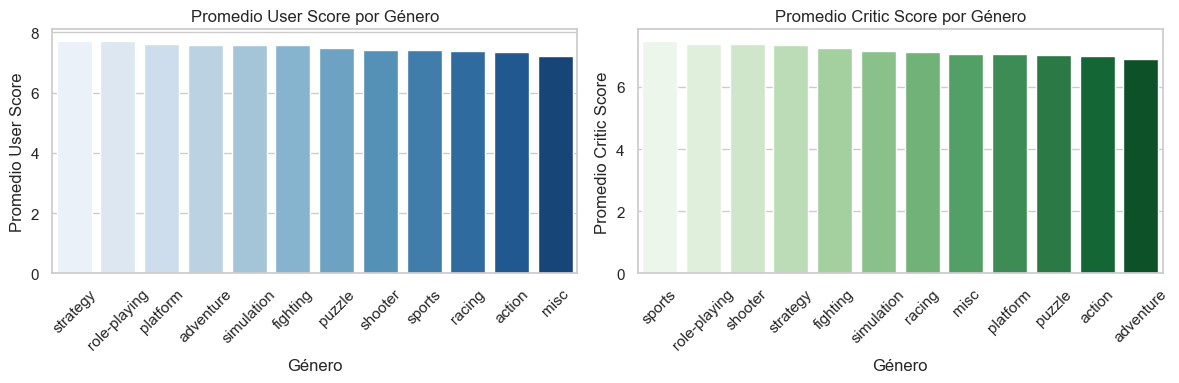

In [141]:
genre_user = (
    df_score_filt['user_score']
    .groupby('genre')['user_score']
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

genre_critic = (
    df_score_filt['critic_score']
    .groupby('genre')['critic_score']
    .mean()
    .sort_values(ascending = False)
    .reset_index()
)

print(genre_user.head())
print(genre_critic.head())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico user_score
sns.barplot(
    data=genre_user,
    x='genre',
    y='user_score',
    hue='genre',
    palette='Blues',
    ax=ax1,
    legend=False
)

ax1.set_title('Promedio User Score por Género')
ax1.set_xlabel('Género')
ax1.set_ylabel('Promedio User Score')
ax1.tick_params(axis='x', rotation=45)

# Gráfico critic_score
sns.barplot(
    data=genre_critic,
    x='genre',
    y='critic_score',
    hue='genre',
    palette='Greens',
    ax=ax2,
    legend=False
)

ax2.set_title('Promedio Critic Score por Género')
ax2.set_xlabel('Género')
ax2.set_ylabel('Promedio Critic Score')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [142]:
df_game = games.copy()

sales_cols = ['na_sales', 'eu_sales', 'jp_sales', 'other_sales']
games['total_sales'] = games[sales_cols].sum(axis=1)


df_game_filt = games[['platform', 'name', 'total_sales']]

df_game_filt.head()

names_unicos = df_game_filt['name'].dropna().unique()
print("Cantidad de juegos únicos:", len(names_unicos))
print(names_unicos[:30])  # muestra los primeros 30

Cantidad de juegos únicos: 11558
<ArrowStringArray>
[                                  'wii sports',
                            'super mario bros.',
                               'mario kart wii',
                            'wii sports resort',
                     'pokemon red/pokemon blue',
                                       'tetris',
                        'new super mario bros.',
                                     'wii play',
                    'new super mario bros. wii',
                                    'duck hunt',
                                   'nintendogs',
                                'mario kart ds',
                  'pokemon gold/pokemon silver',
                                      'wii fit',
                           'kinect adventures!',
                                 'wii fit plus',
                           'grand theft auto v',
                'grand theft auto: san andreas',
                            'super mario world',
 'brain age: trai

In [143]:
gp = (df_game_filt.groupby(['name', 'platform'], as_index=False)['total_sales']
        .sum())

# 2) Juegos que están en 2+ plataformas
multi_names = (gp.groupby('name')['platform']
                 .nunique())
multi_names = multi_names[multi_names >= 2].index

# 3) Top 5 juegos más vendidos (solo multi-plataforma)
top5 = (gp[gp['name'].isin(multi_names)]
          .groupby('name')['total_sales']
          .sum()
          .sort_values(ascending=False)
          .head(5))

top5_names = top5.index.tolist()
print("Top 5 multi-plataforma:", top5_names)

# 4) Tabla pivote para comparar plataformas
pivot_top5 = (gp[gp['name'].isin(top5_names)]
              .pivot_table(index='name',
                           columns='platform',
                           values='total_sales',
                           aggfunc='sum',
                           fill_value=0))

# Mantener el orden del top 5
pivot_top5 = pivot_top5.loc[top5_names]

pivot_top5

Top 5 multi-plataforma: ['grand theft auto v', 'super mario bros.', 'tetris', 'call of duty: black ops', 'call of duty: modern warfare 3']


platform,ds,gb,nes,pc,ps3,ps4,wii,x360,xone
name,,,,,,,,,
grand theft auto v,0.00,0.00,0.00,1.17,21.05,12.62,0.00,16.27,5.47
super mario bros.,0.00,5.07,40.24,0.00,0.00,0.00,0.00,0.00,0.00
tetris,0.00,30.26,5.58,0.00,0.00,0.00,0.00,0.00,0.00
call of duty: black ops,0.58,0.00,0.00,1.62,12.63,0.00,1.37,14.62,0.00
call of duty: modern warfare 3,0.00,0.00,0.00,1.71,13.33,0.00,0.83,14.73,0.00


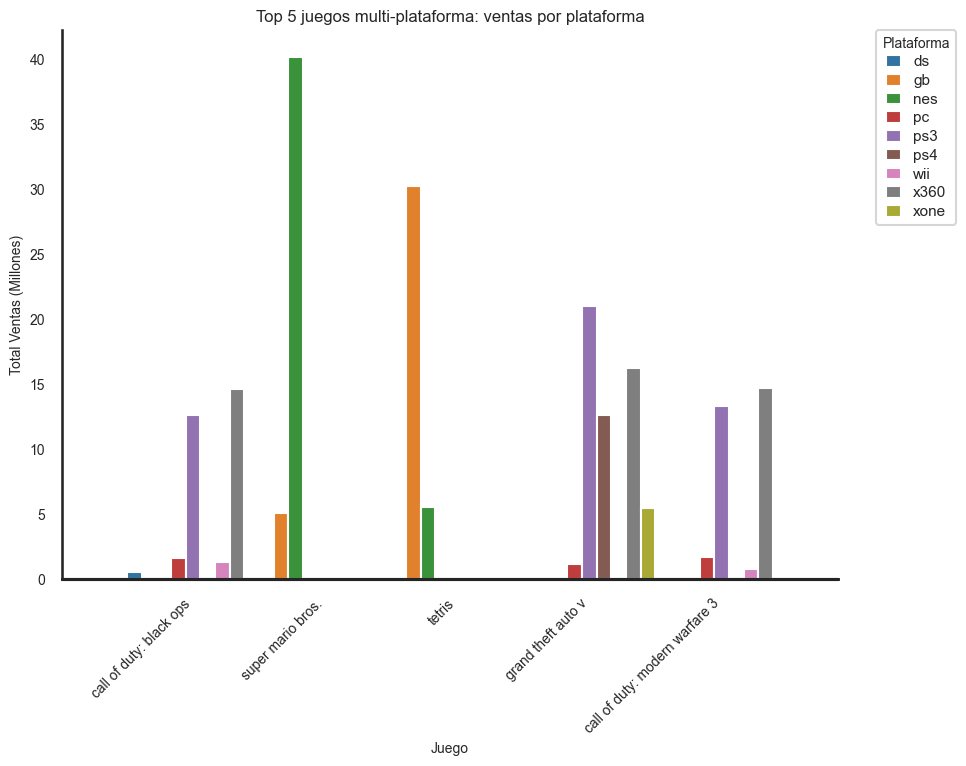

In [144]:
sns.set_theme(style="white", context="talk")

# 1) Pasar la tabla pivote a formato largo
plot_df = (pivot_top5
           .reset_index()  # name vuelve a columna
           .melt(id_vars='name', var_name='platform', value_name='total_sales'))

# 2) Quitar ceros para que no salgan barras vacías
plot_df = plot_df[plot_df['total_sales'] > 0]

platforms = sorted(plot_df['platform'].unique())
palette = sns.color_palette("tab10", n_colors=len(platforms))  # o "tab10" si son <=10


plt.figure(figsize=(10, 8))

ax = sns.barplot(
    data=plot_df,
    x='name',
    y='total_sales',
    hue='platform',
    palette=palette,
    width=1 # prueba 0.95 o 1.0 (más ancho = menos espacio aparente)
)
ax.margins(x=0.1)


plt.axhline(0, color='k', clip_on=False)
plt.xlabel("Juego", fontsize=10)
plt.ylabel("Total Ventas (Millones)", fontsize=10, rotation=90)
plt.title("Top 5 juegos multi-plataforma: ventas por plataforma", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

# Mover la leyenda afuera (y evitar el argumento legend=False)
ax.legend(
    title="Plataforma",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    borderaxespad=0,
    fontsize=11,        # tamaño de texto de items
    title_fontsize=10,  # tamaño del título
    handlelength=1.0,  # largo del cuadrito/linea
    handleheight=0.8,  # alto del cuadrito
    labelspacing=0.3   # espacio entre items
)

sns.despine()
plt.tight_layout()
plt.show()

Géneros con mayor desempeño comercial.

In [145]:
genre_profit = (
    df.assign(
        total_sales = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
    )
    .groupby('genre', as_index=False)['total_sales']
    .sum()
    .sort_values('total_sales', ascending=False)
)

print(genre_profit)


           genre  total_sales
0         action      1744.17
10        sports      1331.27
8        shooter      1052.45
7   role-playing       934.56
4       platform       827.77
3           misc       802.51
6         racing       728.67
2       fighting       447.53
9     simulation       389.97
5         puzzle       242.57
1      adventure       237.59
11      strategy       174.23


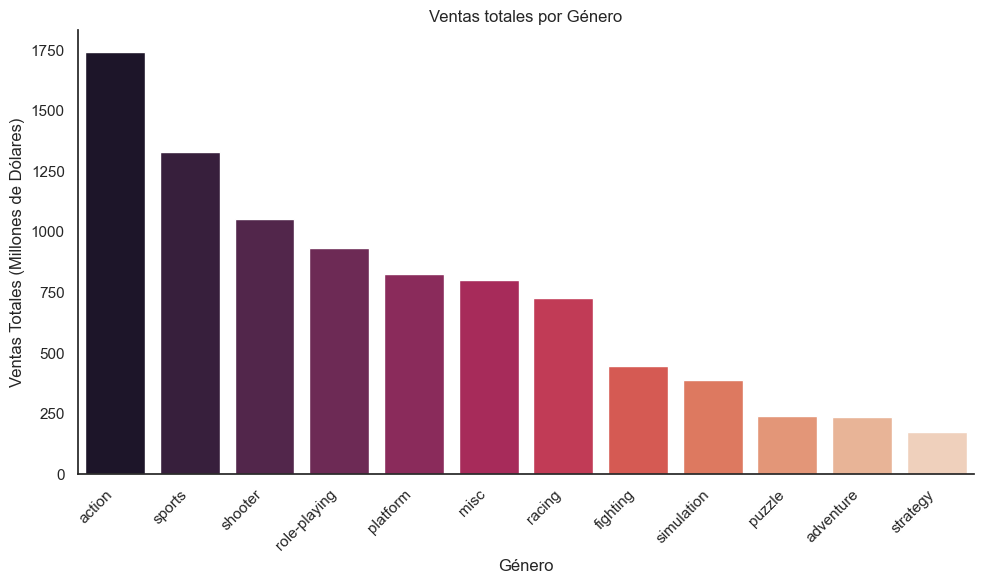

In [146]:
sns.set_theme(style="white")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=genre_profit,
    x='genre',
    y='total_sales',
    hue='genre',       # cada género con color distinto
    palette='rocket',
    dodge=False
)


plt.xticks(rotation=45, ha='right')
plt.title('Ventas totales por Género')
plt.xlabel('Género')
plt.ylabel('Ventas Totales (Millones de Dólares)')
sns.despine()
plt.tight_layout()
plt.show()

In [147]:
genre_profit_mean = (
    df.assign(
        total_sales_mean = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
    )
    .groupby('genre', as_index=False)['total_sales_mean']
    .mean()
    .sort_values('total_sales_mean', ascending=False)
)

print(genre_profit_mean)

           genre  total_sales_mean
4       platform          0.932173
8        shooter          0.795503
7   role-playing          0.623872
6         racing          0.583403
10        sports          0.566980
2       fighting          0.527126
0         action          0.517711
3           misc          0.458577
9     simulation          0.446701
5         puzzle          0.418224
11      strategy          0.255095
1      adventure          0.182341


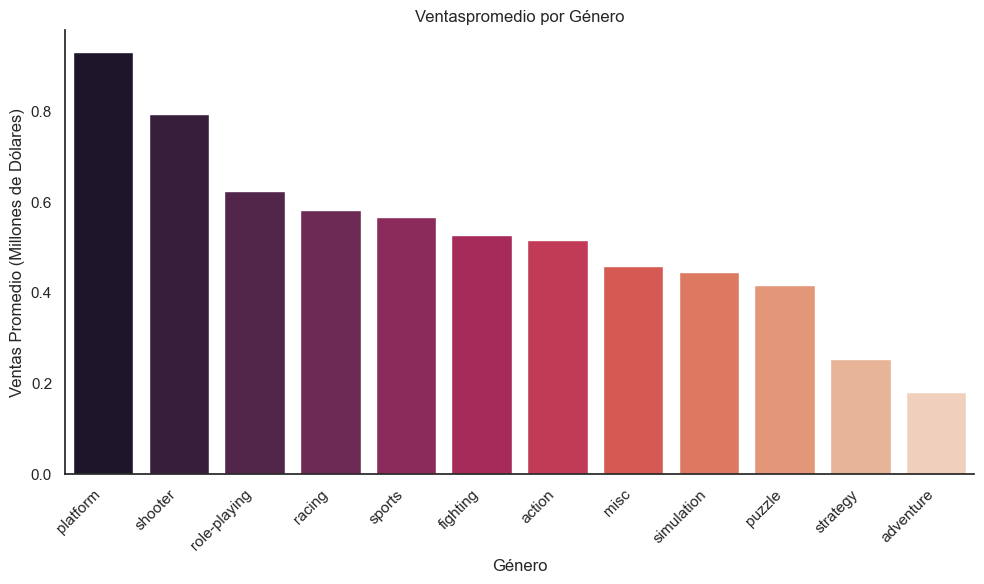

In [148]:
sns.set_theme(style="white")

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=genre_profit_mean,
    x='genre',
    y='total_sales_mean',
    hue='genre',       # cada género con color distinto
    palette='rocket',
    dodge=False
)


plt.xticks(rotation=45, ha='right')
plt.title('Ventaspromedio por Género')
plt.xlabel('Género')
plt.ylabel('Ventas Promedio (Millones de Dólares)')
sns.despine()
plt.tight_layout()
plt.show()

In [149]:
genre_profit_median = (
    df.assign(
        total_sales_median = df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
    )
    .groupby('genre', as_index=False)['total_sales_median']
    .median()
    .sort_values('total_sales_median', ascending=False)
)

print(genre_profit_median)

           genre  total_sales_median
4       platform                0.27
8        shooter                0.24
10        sports                0.22
2       fighting                0.21
0         action                0.19
6         racing                0.19
7   role-playing                0.18
3           misc                0.16
9     simulation                0.15
5         puzzle                0.11
11      strategy                0.10
1      adventure                0.05


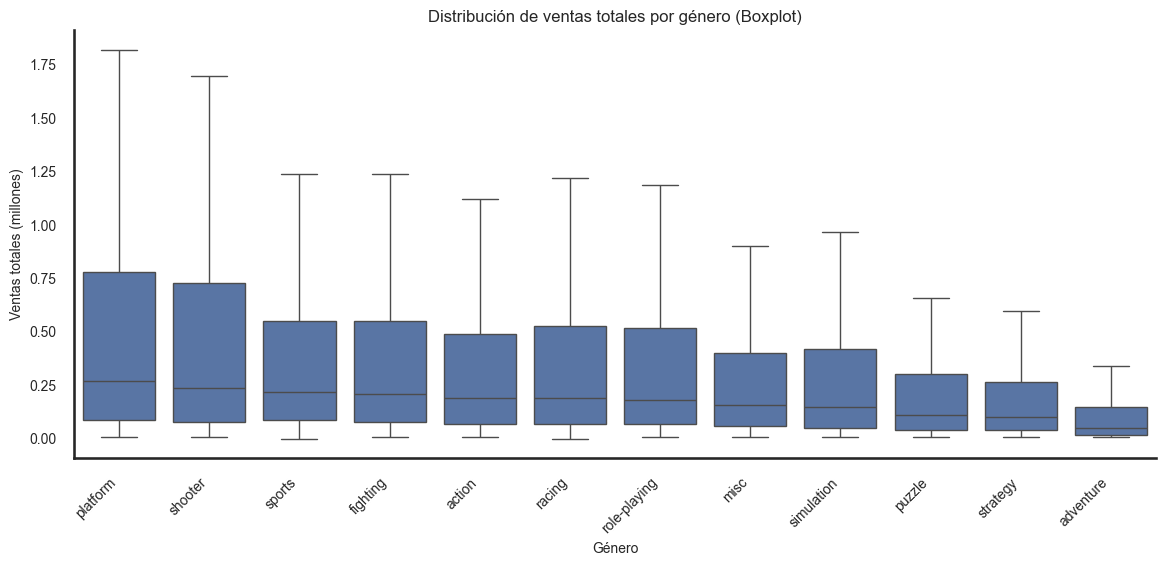

In [150]:
sns.set_theme(style="white", context="talk")

# Datos  por juego/fila 
df_plot = df.assign(
    total_sales_median=df['na_sales'] + df['eu_sales'] + df['jp_sales'] + df['other_sales']
).reset_index(drop=True)

# Ordenar los géneros
order = genre_profit_median['genre'].tolist()

plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    data=df_plot,
    x='genre',
    y='total_sales_median',
    order=order,
    showfliers=False  
)

plt.title("Distribución de ventas totales por género (Boxplot)", fontsize=12)
plt.xlabel("Género", fontsize=10)
plt.ylabel("Ventas totales (millones)", fontsize=10)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

Relación entre User Score, Critic Score y ventas para PS2.

Correlación entre Critic Score y ventas para PS2: 0.389
Correlación entre User Score y ventas para PS2: 0.169


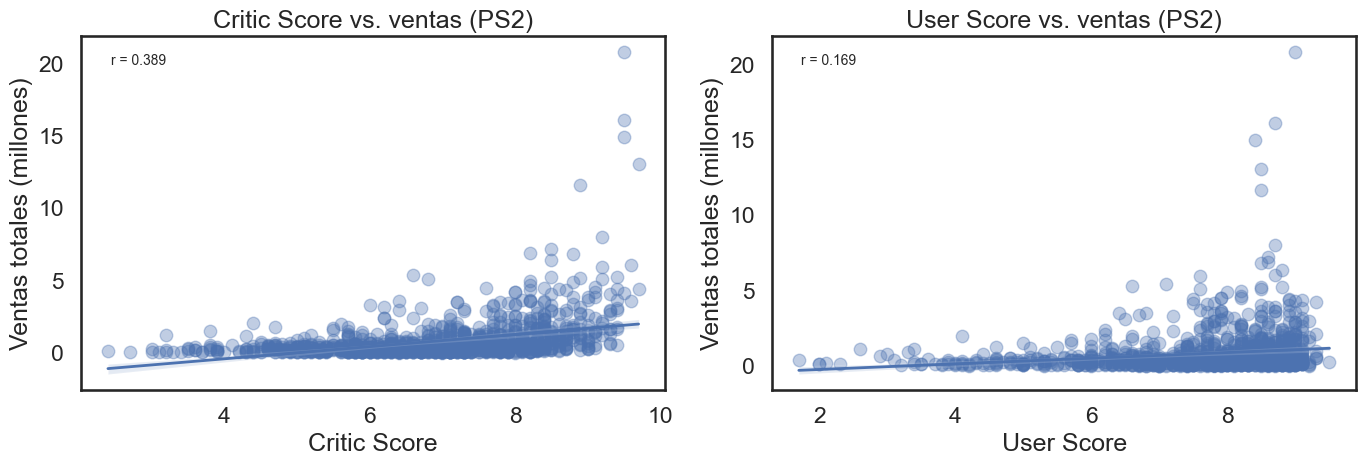

<Figure size 640x480 with 0 Axes>

In [152]:
platform_choice = "ps2"

sales_cols = ["na_sales", "eu_sales", "jp_sales", "other_sales"]

games["total_sales"] = games[sales_cols].sum(axis=1)

platform_scores = (
    games.loc[
        games["platform"] == platform_choice,
        ["critic_score", "user_score", "total_sales"]
    ]
    .dropna()
)

critic_corr = platform_scores["critic_score"].corr(platform_scores["total_sales"])
user_corr = platform_scores["user_score"].corr(platform_scores["total_sales"])

print(f"Correlación entre Critic Score y ventas para {platform_choice.upper()}: {critic_corr:.3f}")
print(f"Correlación entre User Score y ventas para {platform_choice.upper()}: {user_corr:.3f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=platform_scores,
    x="critic_score",
    y="total_sales",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2},
    ax=ax1
)

ax1.set_title("Critic Score vs. ventas (PS2)")
ax1.set_xlabel("Critic Score")
ax1.set_ylabel("Ventas totales (millones)")
ax1.text(0.05, 0.95, f"r = {critic_corr:.3f}", transform=ax1.transAxes, va="top", fontsize=10)

sns.regplot(
    data=platform_scores,
    x="user_score",
    y="total_sales",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2},
    ax=ax2
)

ax2.set_title("User Score vs. ventas (PS2)")
ax2.set_xlabel("User Score")
ax2.set_ylabel("Ventas totales (millones)")
ax2.text(0.05, 0.95, f"r = {user_corr:.3f}", transform=ax2.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


plt.tight_layout()
plt.show()


Para PS2, la relación entre ventas y puntajes no es fuerte: User Score muestra una correlación baja y Critic Score una correlación moderada. Estos resultados indican que User Score y Critic Score pueden aportar contexto sobre recepción, pero deben usarse como señales secundarias, no como predictores principales de ventas.

In [ ]:
df_regions = games.copy()

# Total global
df_regions['global_sales'] = df_regions['na_sales'] + df_regions['eu_sales'] + df_regions['jp_sales'] + df_regions['other_sales']

regions = {'na_sales':'NA', 'eu_sales':'EU', 'jp_sales':'JP', 'other_sales':'OT'}

top_platforms = {}
platform_shares = {}

for col, tag in regions.items():
    tmp = (df_regions.groupby('platform', as_index=False)[col]
              .sum()
              .sort_values(col, ascending=False))
    
    top5 = tmp.head(5).copy()
    total_region = tmp[col].sum()
    top5['share_%'] = (top5[col] / total_region) * 100
    
    top_platforms[tag] = top5
    platform_shares[tag] = top5[['platform','share_%']]

top_platforms['NA'], top_platforms['EU'], top_platforms['JP'], top_platforms['OT']

(   platform  na_sales    share_%
 28     x360    602.47  13.685191
 16      ps2    583.84  13.262008
 25      wii    496.90  11.287153
 17      ps3    393.49   8.938181
 4        ds    382.40   8.686270,
    platform  eu_sales    share_%
 16      ps2    339.29  13.993244
 17      ps3    330.29  13.622060
 28     x360    270.76  11.166880
 25      wii    262.21  10.814255
 15       ps    213.61   8.809859,
    platform  jp_sales    share_%
 4        ds    175.57  13.532762
 15       ps    139.82  10.777188
 16      ps2    139.20  10.729399
 23     snes    116.55   8.983559
 2       3ds    100.67   7.759544,
    platform  other_sales    share_%
 16      ps2       193.44  24.445231
 17      ps3       135.68  17.146034
 28     x360        85.76  10.837588
 25      wii        79.07   9.992165
 4        ds        59.26   7.488753)

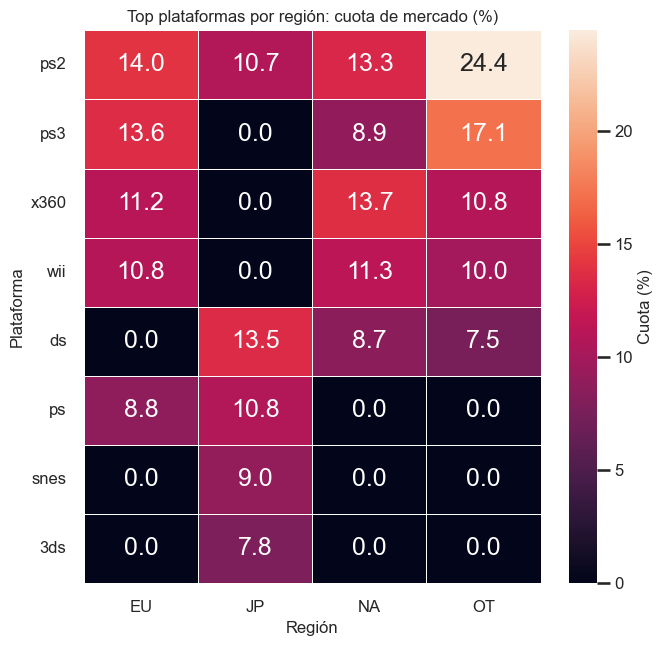

In [ ]:
sns.set_theme(style="white", context="talk")

# Unir los top5 de cada región en una sola tabla 
share_df = (
    pd.concat(
        [platform_shares[tag].assign(region=tag) for tag in ['NA','EU','JP','OT']],
        ignore_index=True
    )
    .pivot_table(index='platform', columns='region', values='share_%', fill_value=0)
)


share_df = share_df.loc[share_df.sum(axis=1).sort_values(ascending=False).index]

# Heatmap 

plt.figure(figsize=(7, 0.6 * len(share_df) + 2))
ax = sns.heatmap(
    share_df,
    annot=True,
    fmt=".1f",
    cmap="rocket",
    linewidths=.5,
    cbar_kws={'label': 'Cuota (%)'}
)

# Título y etiquetas
ax.set_title("Top géneros por región: cuota de mercado (%)", fontsize=12)
ax.set_xlabel("Región", fontsize=12)
ax.set_ylabel("Género", fontsize=12)

# Ticks (valores del eje x e y)
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12, rotation=0)

# Colorbar (escala)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Cuota (%)", fontsize=12)

plt.title("Top plataformas por región: cuota de mercado (%)", fontsize=12)
plt.xlabel("Región")
plt.ylabel("Plataforma")
plt.tight_layout()
plt.show()

In [ ]:
top_genres = {}
genre_shares = {}

for col, tag in regions.items():
    tmp = (df_regions.groupby('genre', as_index=False)[col]
              .sum()
              .sort_values(col, ascending=False))
    top_genres[tag] = tmp.head(5)

top_genres['NA'], top_genres['EU'], top_genres['JP']


for col, tag in regions.items():
    tmp = (df_regions.groupby('genre', as_index=False)[col].sum().sort_values(col, ascending=False))
    total = tmp[col].sum()
    top5 = tmp.head(5).copy()
    top5['share_%'] = (top5[col]/total)*100
    genre_shares[tag] = top5

genre_shares['NA'], genre_shares['EU'], genre_shares['JP'], genre_shares['OT']

(       genre  na_sales    share_%
 0     action    879.01  19.974912
 10    sports    684.43  15.553212
 8    shooter    592.24  13.458257
 4   platform    445.50  10.123689
 3       misc    407.27   9.254937,
       genre  eu_sales    share_%
 0    action    519.13  21.415017
 10   sports    376.79  15.543244
 8   shooter    317.34  13.090828
 6    racing    236.51   9.756450
 3      misc    212.74   8.775896,
            genre  jp_sales    share_%
 7   role-playing    355.41  27.395286
 0         action    161.43  12.443153
 10        sports    135.54  10.447531
 4       platform    130.83  10.084481
 3           misc    108.11   8.333205,
       genre  other_sales    share_%
 0    action       184.60  23.330469
 10   sports       134.51  16.999899
 8   shooter       104.11  13.157828
 6    racing        76.10   9.617815
 3      misc        74.39   9.401699)

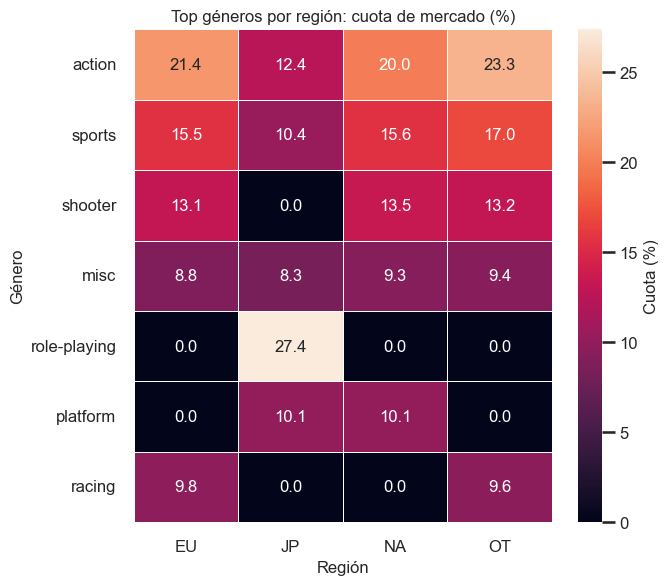

In [ ]:
sns.set_theme(style="white", context="talk")

# Unir top5 de cada región en una sola tabla y pivotear

genre_share_df = (
    pd.concat(
        [genre_shares[tag].assign(region=tag) for tag in ['NA', 'EU', 'JP', 'OT']],
        ignore_index=True
    )
    .pivot_table(index='genre', columns='region', values='share_%', fill_value=0)
)

# ordenar por suma total de cuotas para ver lo más relevante arriba
genre_share_df = genre_share_df.loc[genre_share_df.sum(axis=1).sort_values(ascending=False).index]

# Heatmap
plt.figure(figsize=(7, 0.6 * len(genre_share_df) + 2))
ax = sns.heatmap(
    genre_share_df,
    annot=True,
    fmt=".1f",
    cmap="rocket",
    annot_kws={"size": 12},
    linewidths=.5,
    cbar_kws={'label': 'Cuota (%)'}
)

# Título y etiquetas
ax.set_title("Top géneros por región: cuota de mercado (%)", fontsize=12)
ax.set_xlabel("Región", fontsize=12)
ax.set_ylabel("Género", fontsize=12)

# Ticks (valores del eje x e y)
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12, rotation=0)

# Colorbar (escala)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Cuota (%)", fontsize=12)

plt.title("Top géneros por región: cuota de mercado (%)", fontsize=12)
plt.xlabel("Región")
plt.ylabel("Género")
plt.tight_layout()
plt.show()

Distribución de ESRB Rating por región.

In [ ]:
df_r = df_regions.copy()

# Asegura que no se pierdan filas por rating nulo
df_r['rating'] = df_r['rating'].astype('string').str.strip().str.lower().fillna('unknown')

rating_summary = (df_r.groupby('rating', as_index=False)
                  .agg(
                      n_games=('name', 'count'),
                      na_sum=('na_sales', 'sum'),
                      eu_sum=('eu_sales', 'sum'),
                      jp_sum=('jp_sales', 'sum'),
                      other_sum=('other_sales', 'sum'),
                      na_median=('na_sales', 'median'),
                      eu_median=('eu_sales', 'median'),
                      jp_median=('jp_sales', 'median'),
                      other_median=('other_sales', 'median')
                  ))

# Totales por región (para cuotas)
na_total = rating_summary['na_sum'].sum()
eu_total = rating_summary['eu_sum'].sum()
jp_total = rating_summary['jp_sum'].sum()
other_total = rating_summary['other_sum'].sum()   

rating_summary['na_share_%'] = rating_summary['na_sum'] / na_total * 100
rating_summary['eu_share_%'] = rating_summary['eu_sum'] / eu_total * 100
rating_summary['jp_share_%'] = rating_summary['jp_sum'] / jp_total * 100
rating_summary['other_share_%'] = rating_summary['other_sum'] / other_total * 100

# Ordenar (puedes cambiar por eu_sum/jp_sum)
rating_summary = rating_summary.sort_values('na_sum', ascending=False)

rating_summary.head(15)

,rating,n_games,na_sum,eu_sum,jp_sum,other_sum,na_median,eu_median,jp_median,other_median,na_share_%,eu_share_%,jp_share_%,other_share_%
1,e,3990,1292.99,710.25,198.11,234.17,0.120,0.03,0.00,0.010,29.370450,29.292646,15.270123,29.592327
8,unknown,6764,1242.46,613.83,841.96,151.08,0.000,0.00,0.02,0.000,28.222654,25.316022,64.897446,19.092150
7,t,2961,759.75,427.03,151.40,155.17,0.110,0.04,0.00,0.020,17.257828,17.611881,11.669763,19.609008
5,m,1563,748.48,483.97,64.24,177.10,0.140,0.09,0.00,0.030,17.001829,19.960242,4.951556,22.380327
2,e10+,1420,353.32,188.52,40.20,73.56,0.120,0.03,0.00,0.020,8.025714,7.775079,3.098576,9.295860
4,k-a,3,2.56,0.27,1.46,0.03,0.260,0.10,0.00,0.000,0.058151,0.011136,0.112535,0.003791
3,ec,8,1.53,0.11,0.00,0.11,0.155,0.00,0.00,0.015,0.034754,0.004537,0.000000,0.013901
0,ao,1,1.26,0.61,0.00,0.09,1.260,0.61,0.00,0.090,0.028621,0.025158,0.000000,0.011373
6,rp,3,0.00,0.08,0.00,0.01,0.000,0.03,0.00,0.000,0.000000,0.003299,0.000000,0.001264


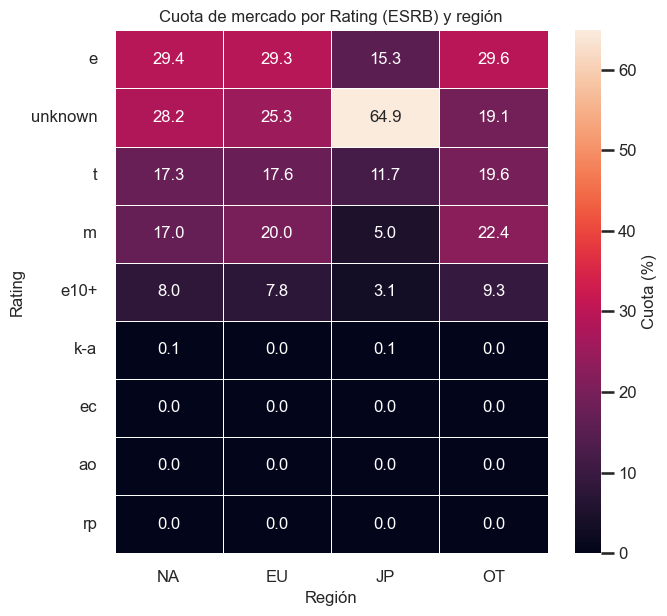

In [ ]:
sns.set_theme(style="white", context="talk")

share_df = (rating_summary
            .set_index('rating')[['na_share_%', 'eu_share_%', 'jp_share_%', 'other_share_%']]
            .rename(columns={'na_share_%':'NA', 'eu_share_%':'EU', 'jp_share_%':'JP', 'other_share_%': 'OT'}))

plt.figure(figsize=(7, 0.5 * len(share_df) + 2))
ax = sns.heatmap(
    share_df,
    annot=True,
    fmt=".1f",
    cmap="rocket",
    linewidths=.5,
    annot_kws={"size": 12},
    cbar_kws={'label': 'Cuota (%)'}
)

ax.set_title("Cuota de mercado por Rating (ESRB) y región", fontsize=12)
ax.set_xlabel("Región", fontsize=12)
ax.set_ylabel("Rating", fontsize=12)
ax.tick_params(axis='x', labelsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Cuota (%)", fontsize=12)

plt.tight_layout()
plt.show()

### Comparaciones estadísticas
Se evalúan dos diferencias de medias en User Score:
- Xbox One vs PC.
- Action vs Sports.

Los resultados se interpretan como evidencia estadística dentro del dataset, no como conclusiones causales ni como reglas generales de mercado.

Xbox One vs PC

In [ ]:
df_calificaciones = games[['platform', 'user_score']]

platforms = ['xone', 'pc']

df_calificaciones = df_calificaciones[
    df_calificaciones['platform'].isin(platforms)
]

df_calificaciones



,platform,user_score
85,pc,7.6
99,xone,NaN
138,pc,7.3
165,xone,7.9
179,xone,5.4
...,...,...
16690,pc,NaN
16692,pc,7.6
16696,pc,5.8
16702,pc,7.2


- Hipótesis nula: H0: μ_xone = μ_pc
- Hipótesis alternativa: H1: μ_xone ≠ μ_pc

In [ ]:
df_calificaciones = games[['platform', 'user_score']].dropna()

xone_scores = df_calificaciones[df_calificaciones['platform'] == 'xone']['user_score']
pc_scores = df_calificaciones[df_calificaciones['platform'] == 'pc']['user_score']

print("Xbox One mean:", xone_scores.mean())
print("PC mean:", pc_scores.mean())

alpha = 0.05

results = stats.ttest_ind(xone_scores, pc_scores, equal_var=False)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Reject the null hypothesis")
else:
    print("Fail to reject the null hypothesis")

print(xone_scores.std(), pc_scores.std())

Xbox One mean: 6.521428571428572
PC mean: 7.062467532467533
p-value: 4.935072360183566e-06
Reject the null hypothesis
1.380940564592144 1.5299631176395092


La prueba t de muestras independientes compara el User Score promedio entre Xbox One y PC. En el dataset, la media observada es 6.52 para Xbox One y 7.06 para PC. El p-value es 0.0000049, inferior al umbral de 0.05, por lo que se rechaza la hipótesis nula.

El resultado apunta a una diferencia estadísticamente significativa en la percepción de usuarios entre estas dos plataformas. Para decisiones de negocio, esta evidencia debe evaluarse junto con el tamaño del efecto, la cobertura de datos y la relevancia comercial de la diferencia observada.

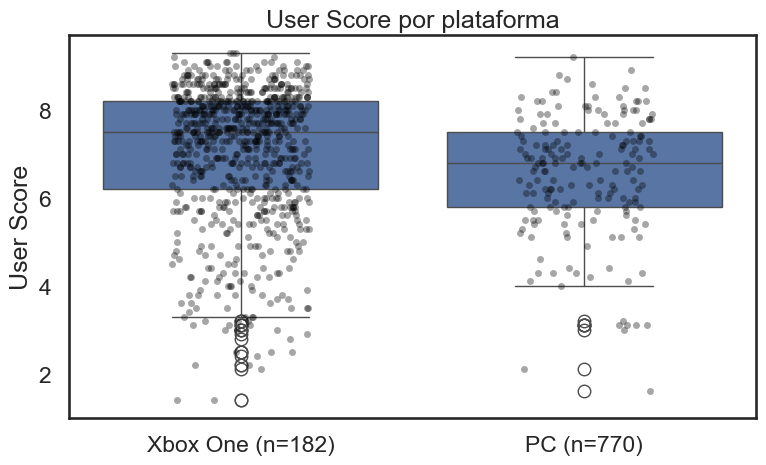

In [ ]:
comparison_df = (
    games.loc[
        games["platform"].isin(["xone", "pc"]),
        ["platform", "user_score"]
    ]
    .dropna()
)

sample_sizes = (
    comparison_df.groupby("platform")
    .size()
)

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=comparison_df,
    x="platform",
    y="user_score"
)

sns.stripplot(
    data=comparison_df,
    x="platform",
    y="user_score",
    alpha=0.35,
    jitter=0.2,
    color="black"
)

plt.xticks(
    [0, 1],
    [
        f"Xbox One (n={sample_sizes['xone']})",
        f"PC (n={sample_sizes['pc']})"
    ]
)

plt.title("User Score por plataforma")
plt.xlabel("")
plt.ylabel("User Score")

plt.tight_layout()
plt.show()

Action y Sports
- Hipótesis nula: H0: μ_action = μ_sports
- Hipótesis alternativa: H1: μ_action ≠ μ_sports

In [ ]:
df_generos = games[['genre', 'user_score']].dropna()

action_scores = df_generos[df_generos['genre'] == 'action']['user_score']
sports_scores = df_generos[df_generos['genre'] == 'sports']['user_score']

print("Action mean:", action_scores.mean())
print("Sports mean:", sports_scores.mean())

print("Action std:", action_scores.std())
print("Sports std:", sports_scores.std())

alpha = 0.05

results = stats.ttest_ind(action_scores, sports_scores, equal_var=False)

print("p-value:", results.pvalue)

if results.pvalue < alpha:
    print("Rechazamos la hipotesis nula")
else:
    print("No podemos rechazar la hipotesis nula")

Action mean: 7.054043715846995
Sports mean: 6.961196736174069
Action std: 1.4253935940761082
Sports std: 1.611370447467932
p-value: 0.11483818791498292
No podemos rechazar la hipotesis nula


La prueba t de muestras independientes compara el User Score promedio entre Action y Sports. Las medias observadas son 7.05 para Action y 6.96 para Sports, con un p-value de 0.1148, superior al umbral de 0.05.

Con estos datos, no se detecta una diferencia estadísticamente significativa entre ambos géneros. User Score por sí solo no separa claramente a Action y Sports como segmentos de calidad percibida; la comparación de géneros debe complementarse con ventas, región, plataforma y otros indicadores de demanda.

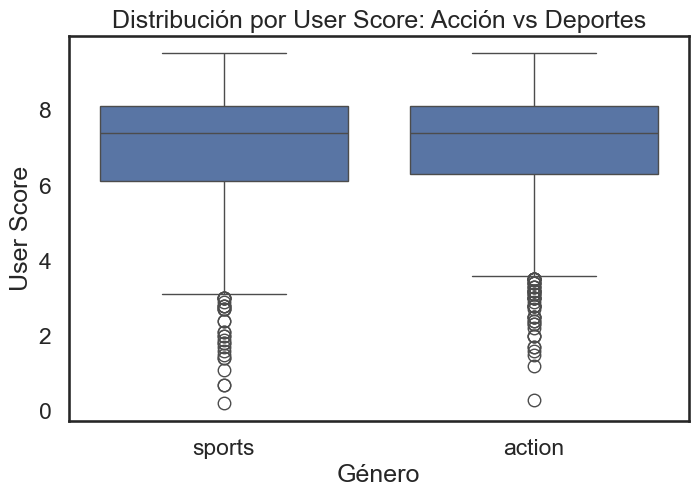

In [ ]:
df_plot = games[games['genre'].isin(['action', 'sports'])][['genre', 'user_score']].dropna()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='genre', y='user_score')
plt.title('Distribución por User Score: Acción vs Deportes')
plt.xlabel('Género')
plt.ylabel('User Score')
plt.show()

### Conclusión ejecutiva

**A. Estructura del Mercado**
Las ventas históricas se concentran en familias de plataformas líderes como PlayStation, Xbox, Wii y DS. Para planificación comercial, esto refuerza la importancia de priorizar plataformas con escala comprobada y presencia regional relevante, sin asumir que la concentración histórica garantiza resultados futuros.

**B. Ciclo de vida de las plataformas**
La vida útil de las plataformas es limitada: la mediana observada es de 7 años y el promedio de 8.6 años. Este ciclo debe considerarse al definir ventanas de campaña, ya que las plataformas cercanas a su madurez o reemplazo pueden requerir criterios distintos frente a plataformas activas y recientes.

**C. Desempeño general por género**
Action, Sports y Role-Playing concentran altos volúmenes de ventas acumuladas. Platform y Shooter muestran un desempeño promedio por título más alto, lo que sugiere que la estrategia de géneros debe equilibrar volumen total, desempeño por juego y contexto regional.

**D. Diferencias regionales y limitaciones del análisis**
Las preferencias regionales varían por plataforma y género, y la distribución de ESRB Rating no es uniforme entre regiones. User Score y Critic Score aportan contexto sobre recepción, pero sus correlaciones con ventas no son suficientemente fuertes para usarse como predictores principales. Las pruebas estadísticas realizadas aplican a comparaciones específicas: Xbox One vs PC y Action vs Sports.

Para la planificación publicitaria de 2017, se recomienda priorizar plataformas recientes y activas, ajustar campañas según demanda regional y combinar desempeño por género con señales de apoyo como User Score, Critic Score y ESRB Rating.